# Training (Kalman Filter)

This notebook contains the code used to perform the main training loop for the Kalman filters. Note that we train two different versions, one with and one without the use of a pseudo-measurement to constrain the keypoints. The actual training code in implemented in `kflearn.py`.

In [3]:
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import kalman
import kflearn
import tracker
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(kalman)
importlib.reload(kflearn)
importlib.reload(tracker)
importlib.reload(dataset);

We now train the Kalman filter with the complete dataset. 

In [ ]:
model = kalman.LearnedPhysics(tracker.build_constrained_physics())

# Train the model for some epochs in the complete dataset.
kflearn.train_epochs_in(50, "../nets/kalman", "../stats/kalman", model)

epoch 0; train: loss 142.38316131211346; val: loss 132.94103860855103
epoch 1; train: loss 134.86237161964152; val: loss 127.12208113303551
epoch 2; train: loss 130.15767605136998; val: loss 123.30142340293297
epoch 3; train: loss 127.25802002904251; val: loss 121.22714647879967
epoch 4; train: loss 125.57223126894644; val: loss 119.85593627049373
epoch 5; train: loss 124.56565074292232; val: loss 119.13141540380624
epoch 6; train: loss 123.93440069944224; val: loss 118.50057502893301
epoch 7; train: loss 123.44338521846998; val: loss 118.13360382960393
epoch 8; train: loss 123.11282195093796; val: loss 117.84462228188148
epoch 9; train: loss 122.85494811685618; val: loss 117.64725971221924
epoch 10; train: loss 122.6552975349732; val: loss 117.38249327586247
epoch 11; train: loss 122.54490782550054; val: loss 117.28683284612802
epoch 12; train: loss 122.35106364086283; val: loss 117.0200970356281
epoch 13; train: loss 122.10174397496591; val: loss 116.79504658625676
epoch 14; train: l

In [5]:
util.NetStorage.training_stats("../stats/kalman").sort_values("step") \
    .to_csv("../stats/kalman.csv", index=False)

#### Training and Validation Loss Curves

Below we will examine the training and validation loss curves for the training run.

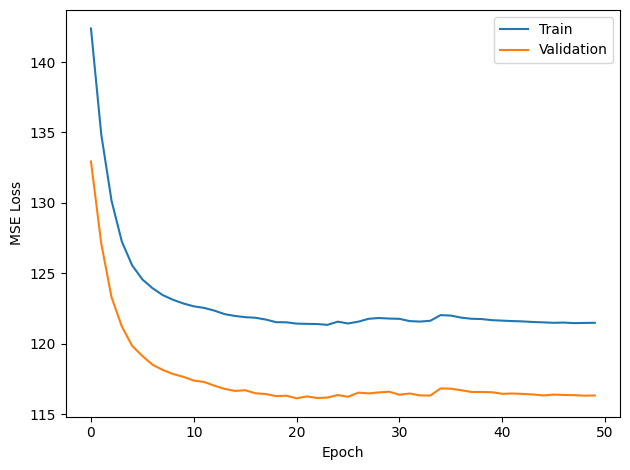

In [7]:
df = pd.read_csv("../stats/kalman.csv").sort_values("step")

plt.plot(df["step"], df["tr_loss"], label="Train")
plt.plot(df["step"], df["val_loss"], label="Validation")
plt.ylabel("MSE Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../presentation1/figures/lcurve-kalman.pdf",
            format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()

Above we can see that the training proceeds well until it hots a minimum around epoch 20, at which point it seems to have hit a local minimum.